In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit, cross_validate
from xgboost import XGBRegressor
from scipy.stats import randint, uniform
from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error, r2_score, make_scorer
from src.Utils import plot_performance_analysis, shifted_mape, mse_column_score
import joblib

<h2>Lectura y Tratamiento de Datos</h2>

In [2]:
X = pd.read_csv('../dataset/dataset_in.txt', index_col=0).drop(columns=['P2', 'Q2'])
y_columns = [f'V{i}' for i in range(2,15)] + ['PERD', 'QGEN7'] #V1 ES SIEMPRE 1.0 EN DATASET
Y = pd.read_csv('../dataset/dataset_out.txt', index_col=0).loc[:, y_columns]
#FILTRAR DATOS ERRÓNEOS (PÉRDIDAS NEGATIVAS)
mask = Y['PERD'] >= 0
X = X[mask]
Y = Y[mask]

**Validación por Retención (Tratamiento como Serie Temporal)**

In [3]:
# VALIDACIÓN POR RETENCIÓN PARA EVALUACIÓN FINAL DEL MEJOR MODELO
n_samples = X.shape[0]
train_size = int(n_samples * 0.8)
x_train, y_train = X[:train_size], Y[:train_size]
x_test, y_test = X[train_size:], Y[train_size:]

<h2>Búsqueda Aleatoria de Hiperparámetros</h2>

In [4]:
random_model = XGBRegressor(objective='reg:squarederror', n_jobs=1, random_state=42)
random_grid = {
    'n_estimators': randint(30, 101),
    'max_depth': randint(3, 9),
    'learning_rate': uniform(0.01, 0.2),
    'colsample_bytree': uniform(0.4, 0.5),
}
random_scoring = {
    'mse_global': 'neg_mean_squared_error',
    'mse_v_perd': make_scorer(mse_column_score, col_idx=[c for c in range(0, Y.shape[1] - 1)], greater_is_better=False),
    'mse_qgen7': make_scorer(mse_column_score, col_idx=-1, greater_is_better=False),
}
random_search = RandomizedSearchCV(random_model, random_grid, n_iter=30,
                                   cv=TimeSeriesSplit(n_splits=3), scoring=random_scoring,
                                   refit='mse_global',
                                   n_jobs=-1, verbose=2, random_state=42, return_train_score=True)

In [5]:
random_search.fit(x_train, y_train)

Fitting 3 folds for each of 30 candidates, totalling 90 fits


,estimator,"XGBRegressor(...ree=None, ...)"
,param_distributions,"{'colsample_bytree': <scipy.stats....001B100658710>, 'learning_rate': <scipy.stats....001B100658210>, 'max_depth': <scipy.stats....001B17BD02210>, 'n_estimators': <scipy.stats....001B1003D5C10>}"
,n_iter,30
,scoring,"{'mse_global': 'neg_mean_squared_error', 'mse_qgen7': make_scorer(m...', col_idx=-1), 'mse_v_perd': make_scorer(m..., 11, 12, 13])}"
,n_jobs,-1
,refit,'mse_global'
,cv,TimeSeriesSpl...est_size=None)
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


<h2>Evaluación del Mejor Modelo Aleatorio</h2>

In [6]:
# PREDICCIONES DEL MEJOR MODELO CON VALORES DEL "FUTURO" X_TEST, YA QUE LO TRATAMOS COMO SERIE TEMPORAL
best_random_model = random_search.best_estimator_
random_predictions = best_random_model.predict(x_test)
print('MSE: ' + str(random_search.best_score_))
random_results = pd.DataFrame(random_search.cv_results_)
random_results.loc[:, ['mean_test_mse_global', 'mean_test_mse_v_perd', 'mean_test_mse_qgen7']]

MSE: -0.013407910553117594


,mean_test_mse_global,mean_test_mse_v_perd,mean_test_mse_qgen7
0,-0.013428,-0.014364,-0.000318
1,-0.032833,-0.035155,-0.000326
2,-0.143298,-0.153478,-0.000782
3,-0.043056,-0.046096,-0.000502
4,-0.017015,-0.018208,-0.000320
5,-0.018670,-0.019981,-0.000315
6,-0.016083,-0.017208,-0.000330
7,-0.046903,-0.050227,-0.000368
8,-0.033054,-0.035391,-0.000334
9,-0.018808,-0.020125,-0.000366


In [7]:
random_MAE = mean_absolute_error(y_test, random_predictions, multioutput='raw_values')
random_MAPE = mean_absolute_percentage_error(y_test, random_predictions, multioutput='raw_values')
#DESPLAZAMIENTO PARA EVITAR DIVISIÓN POR VALORES CERCANO A 0. CONSECUENCIA: MAPE ALGO OPTIMISTA
random_MAPE_shifted = mean_absolute_percentage_error(y_test + 1.0, random_predictions + 1.0, multioutput='raw_values')
random_R2 = r2_score(y_test, random_predictions, multioutput='raw_values')

In [8]:
# RESULTADOS CON MAPE DESPLAZADO
random_data_score_shifted = np.vstack([random_MAE, random_MAPE_shifted, random_R2])
evaluations_shifted = pd.DataFrame(random_data_score_shifted, columns=y_columns, index=['MAE', 'MAPE', 'R2'])
evaluations_shifted

,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,PERD,QGEN7
MAE,0.001743,0.001753,0.001752,0.001724,0.001742,0.001780,0.001710,0.001755,0.001749,0.001788,0.001745,0.001482,0.001670,0.278315,0.007581
MAPE,0.000884,0.000889,0.000889,0.000875,0.000884,0.000903,0.000868,0.000891,0.000887,0.000907,0.000885,0.000749,0.000844,0.031910,0.007133
R2,0.972232,0.972284,0.972525,0.973308,0.972816,0.971679,0.973899,0.972610,0.972764,0.971492,0.972772,0.975495,0.969155,0.974697,0.884619


In [9]:
# RESULTADOS SIN DESPLAZAMIENTO
random_data_score = np.vstack([random_MAE, random_MAPE, random_R2])
evaluations = pd.DataFrame(random_data_score, columns=y_columns, index=['MAE', 'MAPE', 'R2'])
evaluations

,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,PERD,QGEN7
MAE,0.001743,0.001753,0.001752,0.001724,0.001742,0.001780,0.001710,0.001755,0.001749,0.001788,0.001745,0.001482,0.001670,0.278315,7.580600e-03
MAPE,0.001793,0.001805,0.001805,0.001776,0.001794,0.001834,0.001761,0.001808,0.001801,0.001842,0.001798,0.001515,0.001707,0.037302,1.143995e+13
R2,0.972232,0.972284,0.972525,0.973308,0.972816,0.971679,0.973899,0.972610,0.972764,0.971492,0.972772,0.975495,0.969155,0.974697,8.846191e-01


In [10]:
# EVALUACIÓN FINAL CON MEDIA DE VOLTAJES (MAPE DESPLAZADO)
volts_columns = [c for c in y_train.columns if c.startswith('V')]
pd.DataFrame({
    'Voltajes (Desplazados)': evaluations_shifted[volts_columns].mean(axis=1),
    'Pérdidas (Desplazada)': evaluations_shifted['PERD'],
    'Potencia Reactiva (Desplazada)': evaluations_shifted['QGEN7']
})

,Voltajes (Desplazados),Pérdidas (Desplazada),Potencia Reactiva (Desplazada)
MAE,0.001722,0.278315,0.007581
MAPE,0.000873,0.031910,0.007133
R2,0.972541,0.974697,0.884619


In [11]:
# EVALUACIÓN FINAL CON MEDIA DE VOLTAJES (MAPE SIN DESPLAZAMIENTO)
pd.DataFrame({
    'Voltajes': evaluations[volts_columns].mean(axis=1),
    'Pérdidas': evaluations['PERD'],
    'Potencia Reactiva': evaluations['QGEN7']
})

,Voltajes,Pérdidas,Potencia Reactiva
MAE,0.001722,0.278315,7.580600e-03
MAPE,0.001772,0.037302,1.143995e+13
R2,0.972541,0.974697,8.846191e-01


**Validación Cruzada para Contrastación de Resultados**

In [12]:
random_search.best_params_

{'colsample_bytree': np.float64(0.5039708314340945),
 'learning_rate': np.float64(0.1235400655639983),
 'max_depth': 7,
 'n_estimators': 92}

In [13]:
evaluate_model_shifted = XGBRegressor(objective='reg:squarederror', colsample_bytree=0.58, learning_rate=0.2, max_depth=5, n_estimators=90, n_jobs=1, random_state=42)
evaluate_scoring_shifted = { # EVALUACIÓN CON DESPLAZAMIENTO EN MAPE
    'mse': 'neg_mean_squared_error',
    'mae': 'neg_mean_absolute_error',
    'mape': make_scorer(shifted_mape, greater_is_better=False),
    'r2': 'r2'
}
evaluate_results_shifted = cross_validate(evaluate_model_shifted, X, Y, scoring=evaluate_scoring_shifted, cv=TimeSeriesSplit(n_splits=5), n_jobs=-1)
print('MSE: ' + str(-evaluate_results_shifted['test_mse'].mean()))
print('MAE: ' + str(-evaluate_results_shifted['test_mae'].mean()))
print('MAPE: ' + str(-evaluate_results_shifted['test_mape'].mean()))
print('R2: ' + str(evaluate_results_shifted['test_r2'].mean()))

MSE: 0.015291110798716544
MAE: 0.022810887917876242
MAPE: 0.003661406420716693
R2: 0.968291187286377


In [14]:
evaluate_model= XGBRegressor(objective='reg:squarederror', colsample_bytree=0.58, learning_rate=0.2, max_depth=5, n_estimators=90, n_jobs=1, random_state=42)
evaluate_scoring = { # EVALUACIÓN SIN DESPLAMIENTO EN MAPE
    'mse': 'neg_mean_squared_error',
    'mae': 'neg_mean_absolute_error',
    'mape': 'neg_mean_absolute_percentage_error',
    'r2': 'r2'
}
evaluate_results = cross_validate(evaluate_model, X, Y, scoring=evaluate_scoring, cv=TimeSeriesSplit(n_splits=5), n_jobs=-1)
print('MSE: ' + str(-evaluate_results['test_mse'].mean()))
print('MAE: ' + str(-evaluate_results['test_mae'].mean()))
print('MAPE: ' + str(-evaluate_results['test_mape'].mean()))
print('R2: ' + str(evaluate_results['test_r2'].mean()))

MSE: 0.015291110798716544
MAE: 0.022810887917876242
MAPE: 763432665088.0
R2: 0.968291187286377


<h2>Figuras de Rendimiento del Mejor Modelo</h2>

In [15]:
joblib.dump(best_random_model, '../models/MO_XGBoost.pkl')

['../models/MO_XGBoost.pkl']

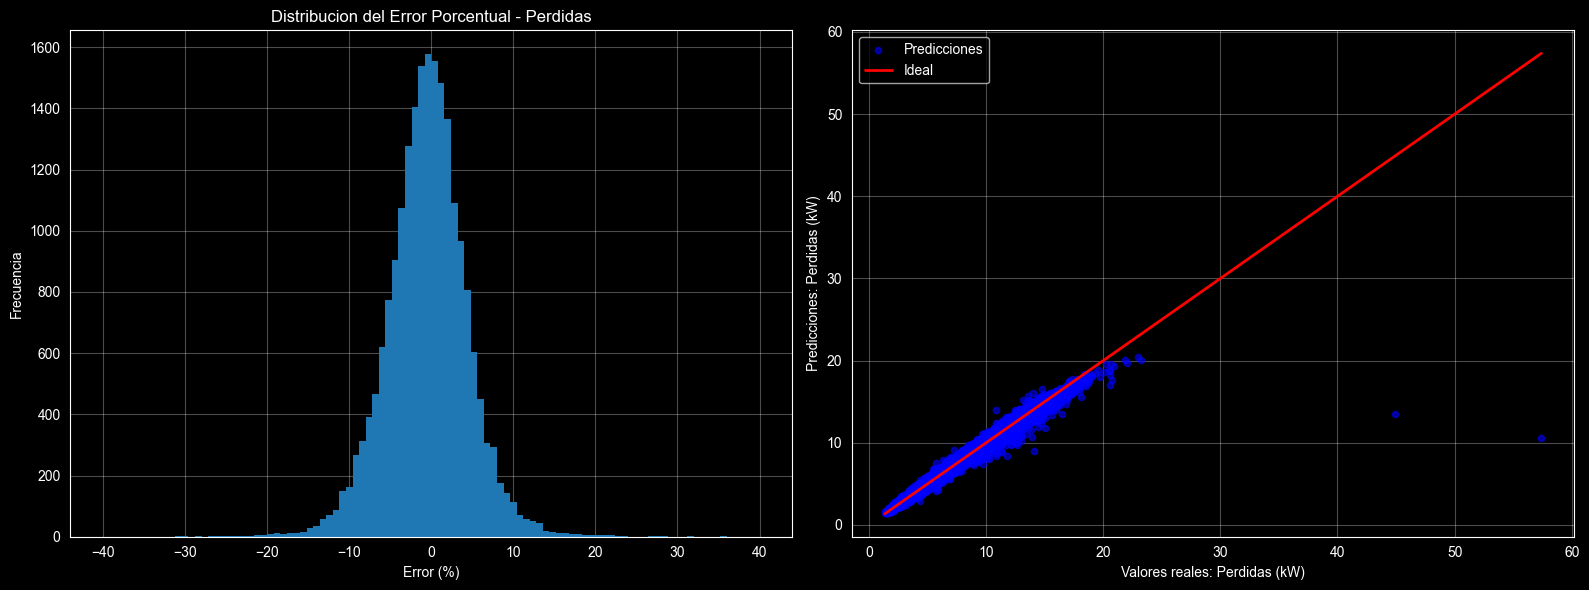

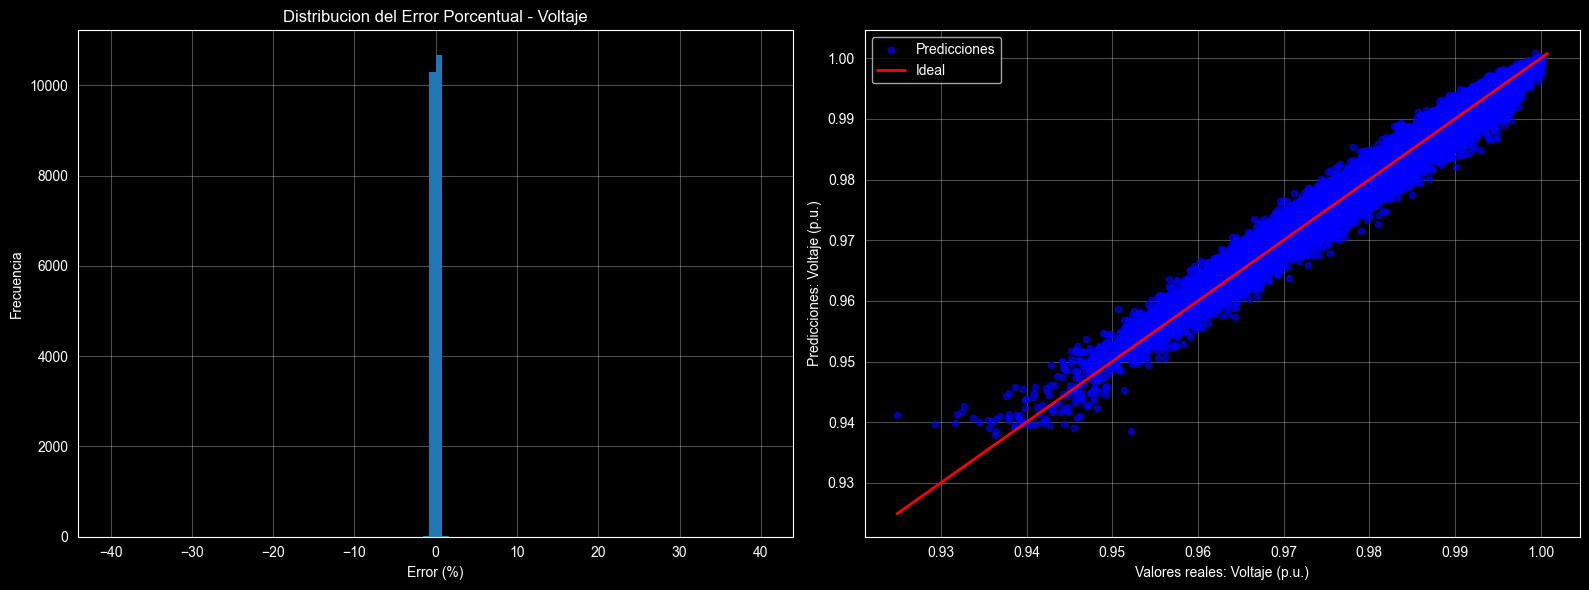

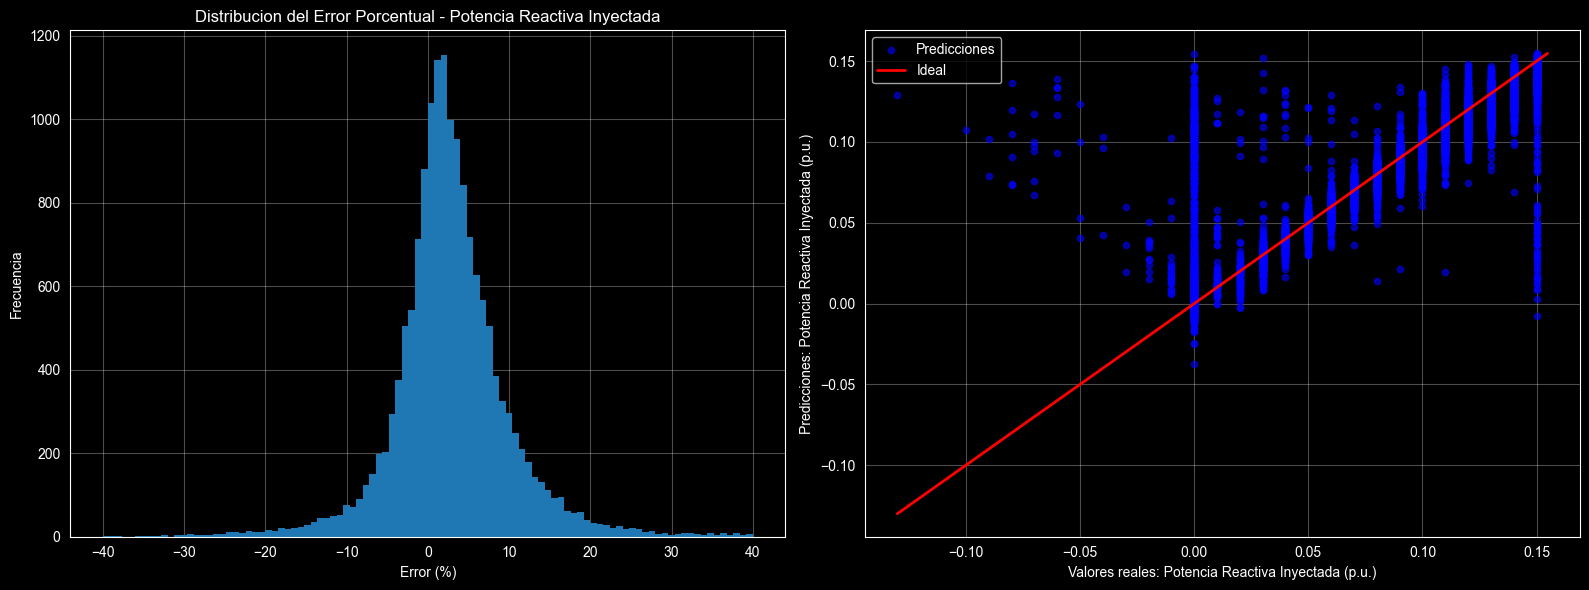

In [16]:
plot_performance_analysis(
    y_test['PERD'],
    random_predictions[:, -2],
    variable_name="Perdidas",
    unit_label="kW",
    path='../figures/XGBoost/MO_XGBoost_Perd.png'
)
plot_performance_analysis(
    y_test['V13'],
    random_predictions[:, -4],
    variable_name="Voltaje",
    unit_label="p.u.",
    path='../figures/XGBoost/MO_XGBoost_V13.png'
)
plot_performance_analysis(
    y_test['QGEN7'],
    random_predictions[:, -1],
    variable_name="Potencia Reactiva Inyectada",
    unit_label="p.u.",
    path='../figures/XGBoost/MO_XGBoost_QGen.png'
)